In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [2]:
# --- Load MNIST dataset from CSV ---
df = pd.read_csv("mnist.csv")
print(df.head())

   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      102      179       92       14      106       71      188       20   
1      209      240      230       95      151      150      189      223   
2       10      253       73      103       37      133      199       22   
3      162      239       69      210      157      198       73      232   
4      163      201      224      182      241       68      174       48   

   pixel_8  pixel_9  ...  pixel_775  pixel_776  pixel_777  pixel_778  \
0      102      121  ...        100        200        151        191   
1       36       11  ...        114        242        163         35   
2       46       89  ...        232         16        103        222   
3      223      225  ...        151         18         99         59   
4      226      107  ...        117         44        160        144   

   pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  label  
0        226        176         98    

In [3]:
# --- Split features and labels ---
X = df.drop(columns=df.columns[0]).values  # All but first column are pixels
y = df[df.columns[0]].values              # First column is label

In [4]:
# --- Normalize pixel values (important for k-NN) ---
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# --- k-NN implementation from scratch ---
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        # Euclidean distances
        distances = [np.sqrt(np.sum((x - x_train) ** 2)) for x_train in self.X_train]
        k_idx = np.argsort(distances)[:self.k]
        k_neighbor_labels = [self.y_train[i] for i in k_idx]
        most_common = Counter(k_neighbor_labels).most_common(1)
        return most_common[0][0]


In [7]:
# --- Reduce dataset for faster testing (optional) ---
# Comment this out if you want full data, but beware: it's slow for k-NN from scratch!
X_train = X_train[:1000]
y_train = y_train[:1000]
X_test = X_test[:200]
y_test = y_test[:200]

In [8]:
# --- Experiment with different k values ---
accuracies = []
k_values = range(1, 11)


In [9]:
for k in k_values:
    model = KNN(k=k)
    model.fit(X_train, y_train)
    
    start = time.time()
    preds = model.predict(X_test)
    end = time.time()
    
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    
    print(f"k = {k}, Accuracy = {acc:.3f}, Time = {end - start:.2f}s")

k = 1, Accuracy = 0.005, Time = 1.47s
k = 2, Accuracy = 0.005, Time = 1.65s
k = 3, Accuracy = 0.005, Time = 1.57s
k = 4, Accuracy = 0.005, Time = 1.69s
k = 5, Accuracy = 0.005, Time = 1.51s
k = 6, Accuracy = 0.005, Time = 1.49s
k = 7, Accuracy = 0.005, Time = 1.52s
k = 8, Accuracy = 0.005, Time = 1.49s
k = 9, Accuracy = 0.005, Time = 1.45s
k = 10, Accuracy = 0.005, Time = 1.46s


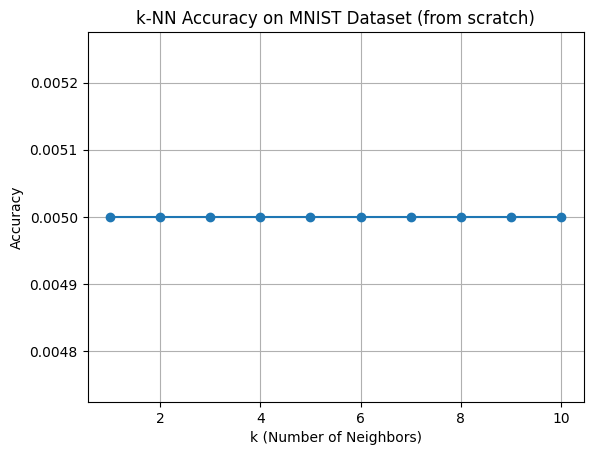

In [10]:
# --- Plot accuracy vs k ---
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy on MNIST Dataset (from scratch)")
plt.grid(True)
plt.show()
